In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
# Set style

In [40]:
df = pd.read_csv('cleaned_cars.csv')
print("Data loaded successfully!")
print(f"Shape: {df.shape}")

Data loaded successfully!
Shape: (8687, 12)


In [41]:
# Select numerical columns
numerical_cols = ['Year','Age','kmDriven','AskPrice']
print("Numerical Columns: ",numerical_cols)

Numerical Columns:  ['Year', 'Age', 'kmDriven', 'AskPrice']


In [42]:
# Summary Statistics
print("\n Summary Statistics:")
df[numerical_cols].describe()


 Summary Statistics:


,Year,Age,kmDriven,AskPrice
count,8687.000000,8687.000000,8687.000000,8.687000e+03
mean,2016.073098,7.926902,72708.137677,6.865625e+05
std,4.091552,4.091552,56744.643379,4.780655e+05
min,1986.000000,0.000000,0.000000,1.500000e+04
25%,2014.000000,5.000000,46000.000000,3.450000e+05
50%,2016.000000,8.000000,67000.000000,5.500000e+05
75%,2019.000000,10.000000,87000.000000,8.950000e+05
max,2024.000000,38.000000,980002.000000,2.271000e+06


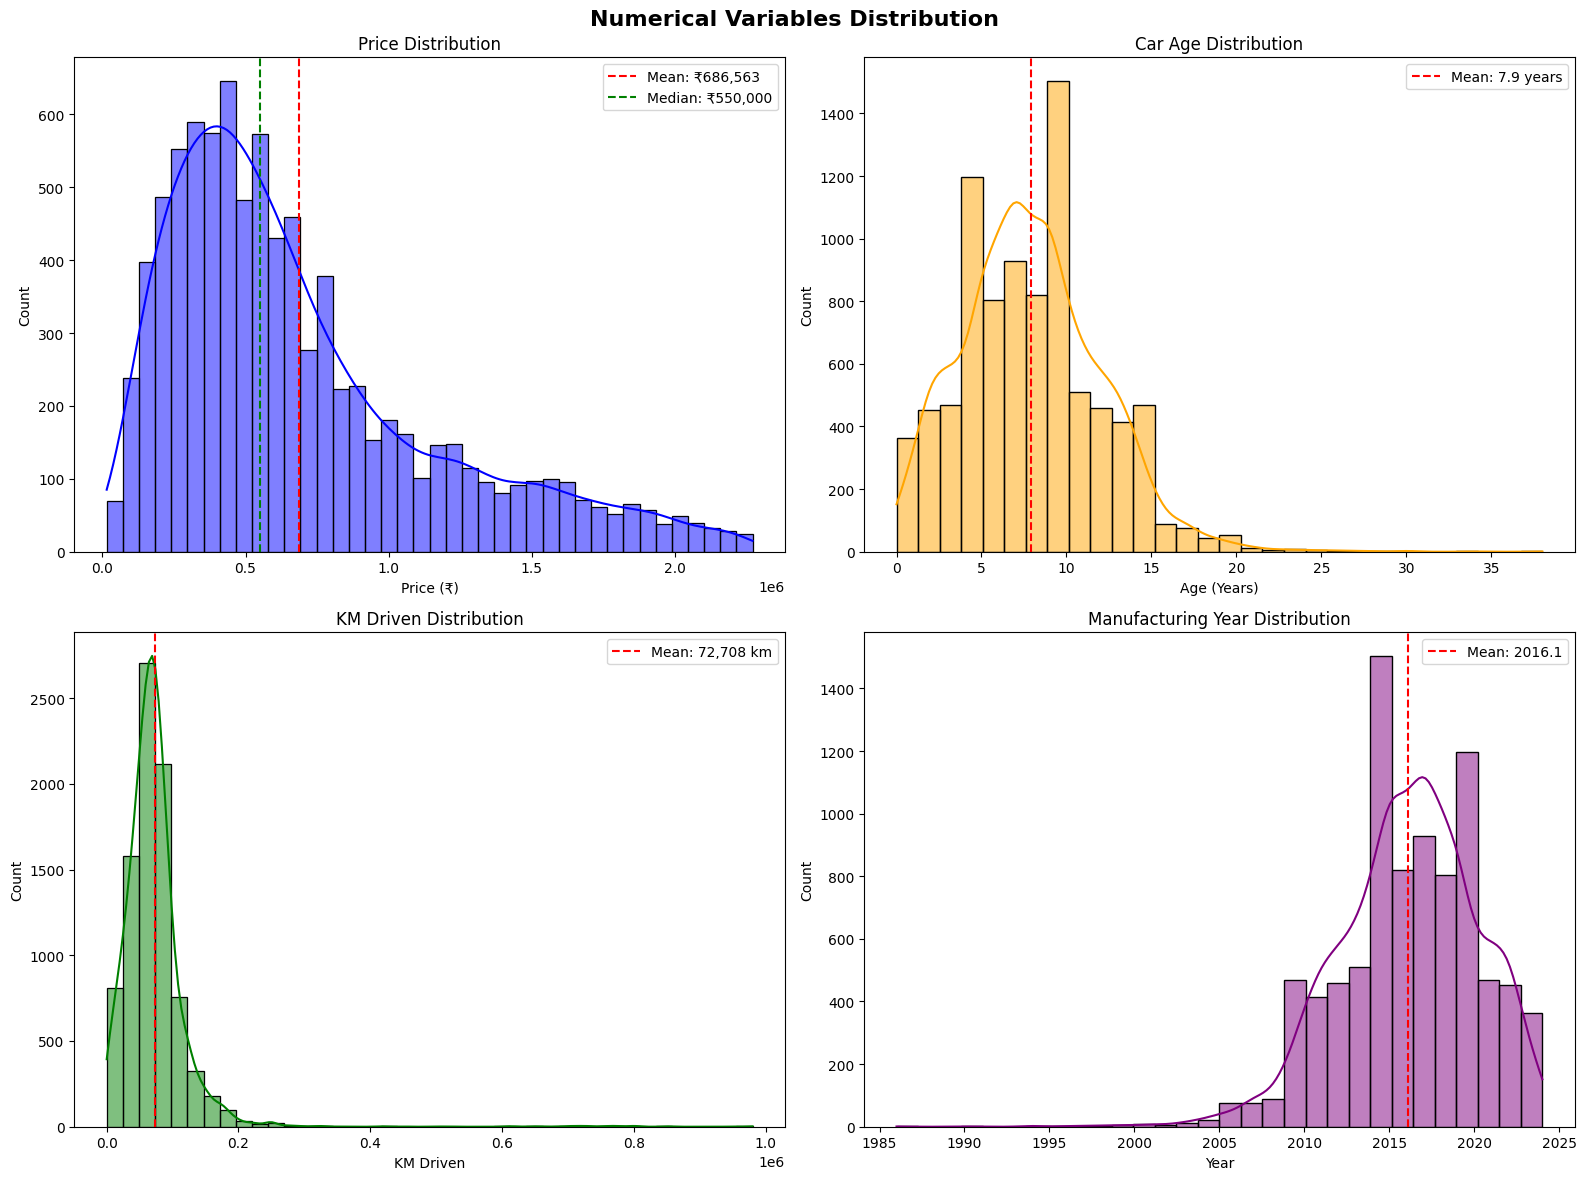

In [43]:
# Create distribution charts for numerical variables
fig, axes = plt.subplots(2,2, figsize=(16,12))
fig.suptitle('Numerical Variables Distribution', fontsize = 16, fontweight = 'bold')
# Price Distribution
sns.histplot(df['AskPrice'], kde=True, ax=axes[0,0], color='blue', bins=40)
axes[0,0].set_title('Price Distribution')
axes[0,0].set_xlabel('Price (₹)')
axes[0,0].axvline(df['AskPrice'].mean(), color='red', linestyle='--', 
                  label=f'Mean: ₹{df["AskPrice"].mean():,.0f}')
axes[0,0].axvline(df['AskPrice'].median(), color='green', linestyle='--', 
                  label=f'Median: ₹{df["AskPrice"].median():,.0f}')
axes[0,0].legend()

# Age Distribution
sns.histplot(df['Age'], kde=True, ax=axes[0,1], color='orange', bins=30)
axes[0,1].set_title('Car Age Distribution')
axes[0,1].set_xlabel('Age (Years)')
axes[0,1].axvline(df['Age'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {df["Age"].mean():.1f} years')
axes[0,1].legend()

# KM Driven Distribution
sns.histplot(df['kmDriven'], kde=True, ax=axes[1,0], color='green', bins=40)
axes[1,0].set_title('KM Driven Distribution')
axes[1,0].set_xlabel('KM Driven')
axes[1,0].axvline(df['kmDriven'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {df["kmDriven"].mean():,.0f} km')
axes[1,0].legend()

# Year Distribution
sns.histplot(df['Year'], kde=True, ax=axes[1,1], color='purple', bins=30)
axes[1,1].set_title('Manufacturing Year Distribution')
axes[1,1].set_xlabel('Year')
axes[1,1].axvline(df['Year'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {df["Year"].mean():.1f}')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
# Skewness analysis
print("=" * 50)
print("SKEWNESS ANALYSIS")
print("=" * 50)
for col in numerical_cols:
    skewness = df[col].skew()
    if abs(skewness) < 0.5:
        interpretation = "Normal distribution"
    elif skewness > 0:
        interpretation = "Right-skewed (most values on left)"
    else:
        interpretation = "Left-skewed (most values on right)"
    print(f"{col}: {skewness:.2f} - {interpretation}")

SKEWNESS ANALYSIS
Year: -0.57 - Left-skewed (most values on right)
Age: 0.57 - Right-skewed (most values on left)
kmDriven: 6.95 - Right-skewed (most values on left)
AskPrice: 1.18 - Right-skewed (most values on left)


In [45]:
# Select categorical columns
categorical_cols = ['Brand', 'Transmission', 'Owner', 'FuelType']
print("Categorical Columns:", categorical_cols)

Categorical Columns: ['Brand', 'Transmission', 'Owner', 'FuelType']


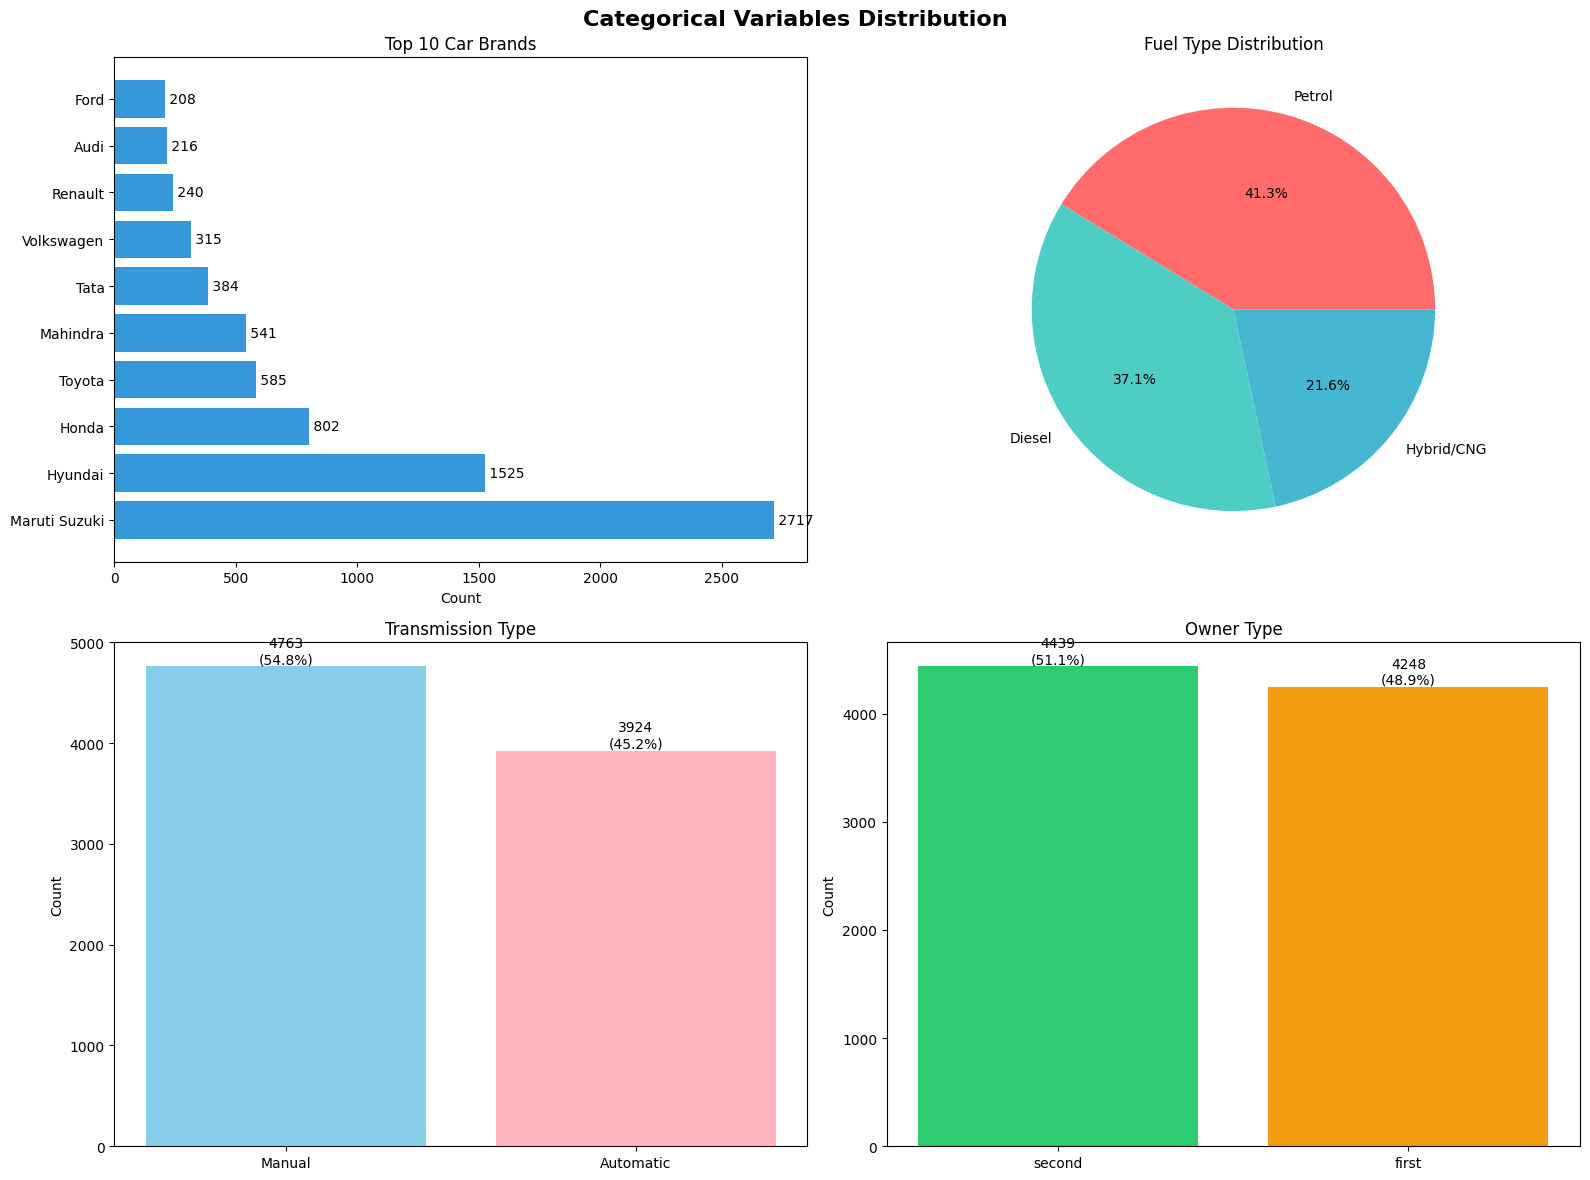

In [46]:
# Create distribution charts for categorical variables
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Categorical Variables Distribution', fontsize=16, fontweight='bold')

# Top 10 Brands
top_brands = df['Brand'].value_counts().head(10)
bars = axes[0,0].barh(top_brands.index, top_brands.values, color='#3498db')
axes[0,0].set_title('Top 10 Car Brands')
axes[0,0].set_xlabel('Count')
for i, bar in enumerate(bars):
    width = bar.get_width()
    axes[0,0].text(width, bar.get_y() + bar.get_height()/2, 
                   f' {int(width)}', ha='left', va='center')

# Fuel Type
fuel_counts = df['FuelType'].value_counts()
axes[0,1].pie(fuel_counts.values, labels=fuel_counts.index, autopct='%1.1f%%',
              colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[0,1].set_title('Fuel Type Distribution')

# Transmission
trans_counts = df['Transmission'].value_counts()
bars = axes[1,0].bar(trans_counts.index, trans_counts.values, 
                     color=['#87CEEB', '#FFB6C1'])
axes[1,0].set_title('Transmission Type')
axes[1,0].set_ylabel('Count')
for bar in bars:
    height = bar.get_height()
    axes[1,0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}\n({height/len(df)*100:.1f}%)',
                   ha='center', va='bottom')

# Owner Type
owner_counts = df['Owner'].value_counts()
bars = axes[1,1].bar(owner_counts.index, owner_counts.values, 
                     color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1,1].set_title('Owner Type')
axes[1,1].set_ylabel('Count')
for bar in bars:
    height = bar.get_height()
    axes[1,1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}\n({height/len(df)*100:.1f}%)',
                   ha='center', va='bottom')

plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
# Value counts with percentages
print("=" * 50)
print("CATEGORICAL VARIABLES BREAKDOWN")
print("=" * 50)

for col in categorical_cols:
    print(f"\n📊 {col}:")
    value_counts = df[col].value_counts()
    for value, count in value_counts.head(5).items():
        percentage = (count / len(df)) * 100
        print(f"   {value}: {count:,} ({percentage:.1f}%)")
    if len(value_counts) > 5:
        print(f"   ... and {len(value_counts)-5} more categories")

CATEGORICAL VARIABLES BREAKDOWN

📊 Brand:
   Maruti Suzuki: 2,717 (31.3%)
   Hyundai: 1,525 (17.6%)
   Honda: 802 (9.2%)
   Toyota: 585 (6.7%)
   Mahindra: 541 (6.2%)
   ... and 30 more categories

📊 Transmission:
   Manual: 4,763 (54.8%)
   Automatic: 3,924 (45.2%)

📊 Owner:
   second: 4,439 (51.1%)
   first: 4,248 (48.9%)

📊 FuelType:
   Petrol: 3,584 (41.3%)
   Diesel: 3,223 (37.1%)
   Hybrid/CNG: 1,880 (21.6%)


In [48]:
# Top 5 Models
print("=" * 50)
print("TOP 5 CAR MODELS")
print("=" * 50)
top_models = df['model'].value_counts().head(5)
for model, count in top_models.items():
    print(f"   {model}: {count:,} cars ({count/len(df)*100:.1f}%)")

TOP 5 CAR MODELS
   City: 330 cars (3.8%)
   Wagon-R: 311 cars (3.6%)
   Swift: 283 cars (3.3%)
   Creta: 259 cars (3.0%)
   Ertiga: 249 cars (2.9%)


In [50]:
# Filter to months with actual listings (drop zeros)
monthly_listings = df['PostedMonth'].value_counts().sort_index()
monthly_listings = monthly_listings[monthly_listings > 0]  # Remove zeros

plt.figure(figsize=(12, 6))
bars = plt.bar(monthly_listings.index, monthly_listings.values, color='#e67e22')

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.title('Car Listings by Month (Dec 2023 - Nov 2024)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', alpha=0.3)
plt.show()

KeyError: 'PostedMonth'

 Day 3 Summary
 
 What I Did Today:
 - ✅ Analyzed numerical variables (Price, Age, KM, Year)
 - ✅ Analyzed categorical variables (Brand, Fuel, Transmission, Owner)
 - ✅ Created distribution charts
 - ✅ Calculated skewness for numerical columns
 - ✅ Identified top brands and models
 - ✅ Analyzed monthly listing patterns
 
 Key Findings:
 1. **Price**: Right-skewed, most cars under ₹8 lakhs
 2. **Age**: Average car is 7 years old
 3. **KM Driven**: Most cars driven 50,000-80,000 km
 4. **Brand**: Maruti Suzuki dominates (28% market share)
 5. **Fuel**: Diesel and Petrol are most common
 6. **Transmission**: Manual is more common (50%+)
 7. **Owner**: First owner cars are majority
 8. **Listings**: Peak in November 2024

In [51]:
df.head()

,Unnamed: 0,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,0,Honda,City,2001,23,98000.0,Manual,second,Petrol,2024-11-01,"Honda City v teck in mint condition, valid gen...",195000
1,1,Toyota,Innova,2009,15,190000.0,Manual,second,Diesel,2024-07-01,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...",375000
2,2,Volkswagen,VentoTest,2010,14,77246.0,Manual,first,Diesel,2024-11-01,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...",184999
3,3,Maruti Suzuki,Swift,2017,7,83500.0,Manual,second,Diesel,2024-11-01,Maruti Suzuki Swift 2017 Diesel Good Condition,565000
4,4,Maruti Suzuki,Baleno,2019,5,45000.0,Automatic,first,Petrol,2024-11-01,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol",685000
